# Complex Systems Eportofolio: Module 2


### link to dataset
https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

### link to paper
https://www.semanticscholar.org/paper/Assessing-Beijing's-PM2.5-pollution%3A-severity%2C-APEC-Liang-Zou/8a82cccc111cbe3e7ff7bc16a3345afe8351a425

In [17]:
# @title Import packages
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
import math
from statsmodels.tsa.stattools import adfuller


In [20]:
# @title Uploading dataset
df = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv')

In [21]:
# @title Checking and describing columns
df.columns
'''
No:     row number
year:   year of data in this row
month:  month of data in this row
day:    day of data in this row
hour:   hour of data in this row

pm2.5:  PM2.5 concentration (ug/m^3)
        The main pollutants are fine particulate matter, and PM2.5 in particular [1,2].
        PM2.5 consists of airborne particles with aerodynamic diameters of less than 2.5 μm.
        They are known to influence visibility, human health and even climate [3].
        Epidemiological evidence shows that exposure to PM2.5 can cause lung morbidity [4],
        serious respiratory and cardiovascular diseases, and even death


        We first provide a set of descriptive statistics on the extent of the PM2.5 pollution in Beijing.
        According to the US (EPA) standard, 35 μg m−3 (the European Union uses 25 μg m−3) is the highest
        PM2.5 level for acceptable air quality, while 150 μg m−3 is widely viewed as very unhealthy and even hazardous.

        We partition the PM2.5 time series into three states: low PM state when PM2.5 ≤35 μg m−3; polluting episode
        when PM2.5>35 μg m−3; and very high PM when PM2.5>150 μg m−3.


        Wind speed is known to be influential in PM2.5 for studies on the US data

DEWP:   Dew Point (â„ƒ)
        Dew point temperature is the temperature at which air becomes fully saturated with water vapor and must cool to initiate condensation, forming dew, fog, or clouds

TEMP:   Temperature (â„ƒ)
PRES:   Pressure (hPa)
cbwd:   Combined wind direction
Iws:    Cumulated wind speed (m/s)
Is:     Cumulated hours of snow
Ir:     Cumulated hours of rain
'''

'\nNo:     row number\nyear:   year of data in this row\nmonth:  month of data in this row\nday:    day of data in this row\nhour:   hour of data in this row\n\npm2.5:  PM2.5 concentration (ug/m^3)\n        The main pollutants are fine particulate matter, and PM2.5 in particular [1,2].\n        PM2.5 consists of airborne particles with aerodynamic diameters of less than 2.5\u2009μm.\n        They are known to influence visibility, human health and even climate [3].\n        Epidemiological evidence shows that exposure to PM2.5 can cause lung morbidity [4],\n        serious respiratory and cardiovascular diseases, and even death\n\n\n        We first provide a set of descriptive statistics on the extent of the PM2.5 pollution in Beijing.\n        According to the US (EPA) standard, 35\u2009μg\u2009m−3 (the European Union uses 25\u2009μg\u2009m−3) is the highest\n        PM2.5 level for acceptable air quality, while 150\u2009μg\u2009m−3 is widely viewed as very unhealthy and even hazardo

In [22]:
# @title Some checking data
print(df.head())

   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0


In [23]:
# @title Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [24]:
# @title Describing
df.describe()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [25]:
# @title Checking for missing values

df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,2067
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [26]:
# @title Fixing pm2.5 with linear values with the days before after kind of thing

# The values will be replaced with the linear method as it compares witht the days before and after
df['pm2.5'] = df['pm2.5'].interpolate(method='linear')

# the remaining will be replaced with the next value of the day
df['pm2.5'] = df['pm2.5'].fillna(method='bfill').fillna(method='ffill')

df.isna().sum()

# fixed it lol

/tmp/ipykernel_339/300272976.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['pm2.5'] = df['pm2.5'].fillna(method='bfill').fillna(method='ffill')


,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,0
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [27]:
# @title  label encoding cbwd

# This is the wind-direction etc...
print(df['cbwd'].unique())

# 'NW' --> North West               0
# 'cv' --> calm and variable        1
# 'NE' --> North East               2
# 'SE' --> South East               3


label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(df["cbwd"])


print(list(label_encoder.classes_))
print()
print(label_encoder.transform(df["cbwd"]))

df["cbwd_encoded"] = label_encoder.transform(df["cbwd"])


df = df.drop(columns=['cbwd'])


['NW' 'cv' 'NE' 'SE']
['NE', 'NW', 'SE', 'cv']

[1 1 1 ... 1 1 1]


In [28]:
# @title Checking out the cbwd_encoded
print(df['cbwd_encoded'].value_counts())

# 'NW' --> North West               0 --> 4997
# 'cv' --> calm and variable        1 --> 14150
# 'NE' --> North East               2 --> 15290
# 'SE' --> South East               3 --> 9387

cbwd_encoded
2    15290
1    14150
3     9387
0     4997
Name: count, dtype: int64


In [37]:
# @title Making the datetime
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])
df = df.set_index('datetime')

In [32]:
# @ title dropping NA valuables
series = df['pm2.5'].dropna()

## Here Lexi explains the questions with code
  
    2. Does the temporal signature change over time? In other words, is the time series stationary?
  
    4. What effect does upsampling and downsampling have on the temporal signature?



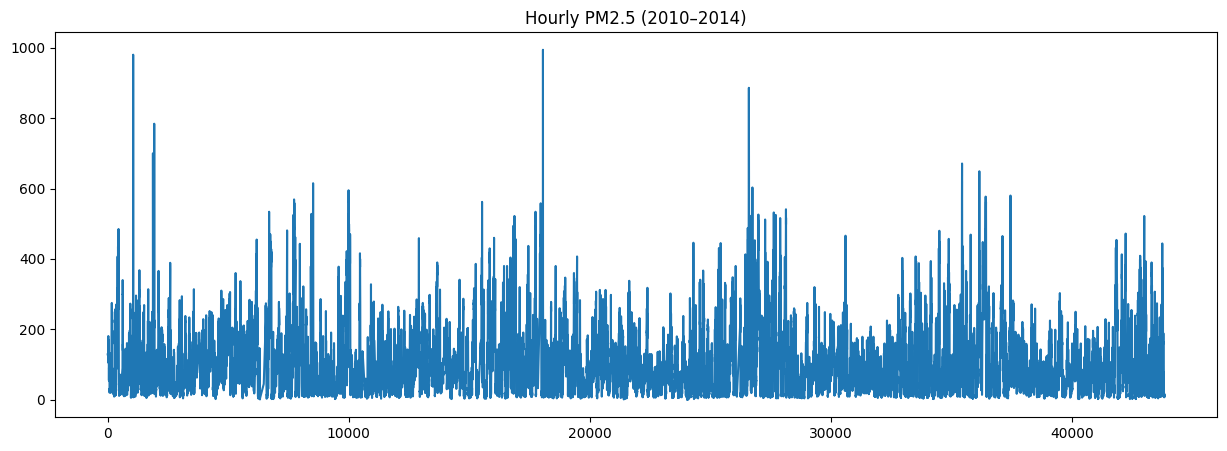

In [30]:

series = df['pm2.5'].dropna()

plt.figure(figsize=(15,5))
plt.plot(series)
plt.title("Hourly PM2.5 (2010–2014)")
plt.show()

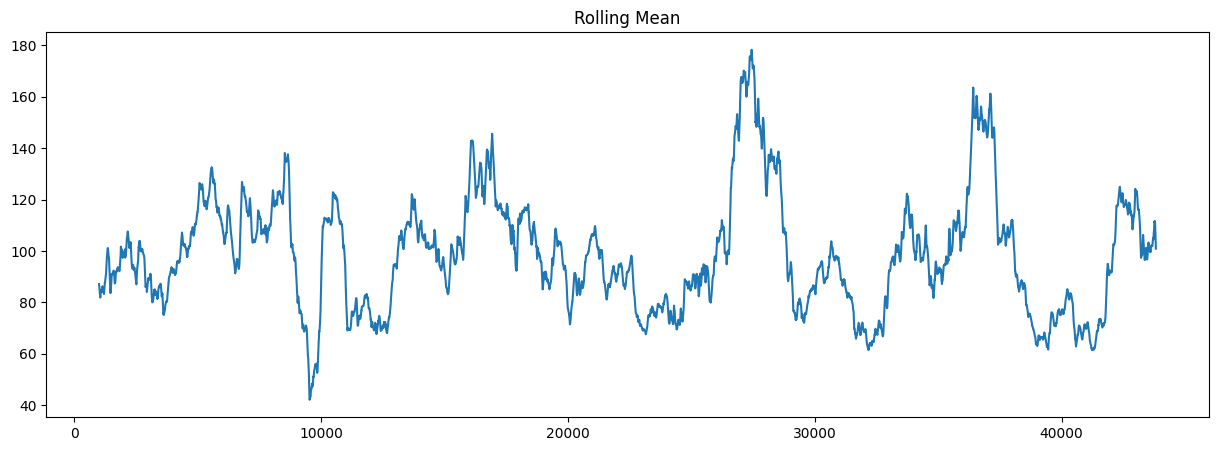

In [33]:

rolling_mean = series.rolling(1000).mean()
rolling_std = series.rolling(1000).std()

plt.figure(figsize=(15,5))
plt.plot(rolling_mean)
plt.title("Rolling Mean")
plt.show()

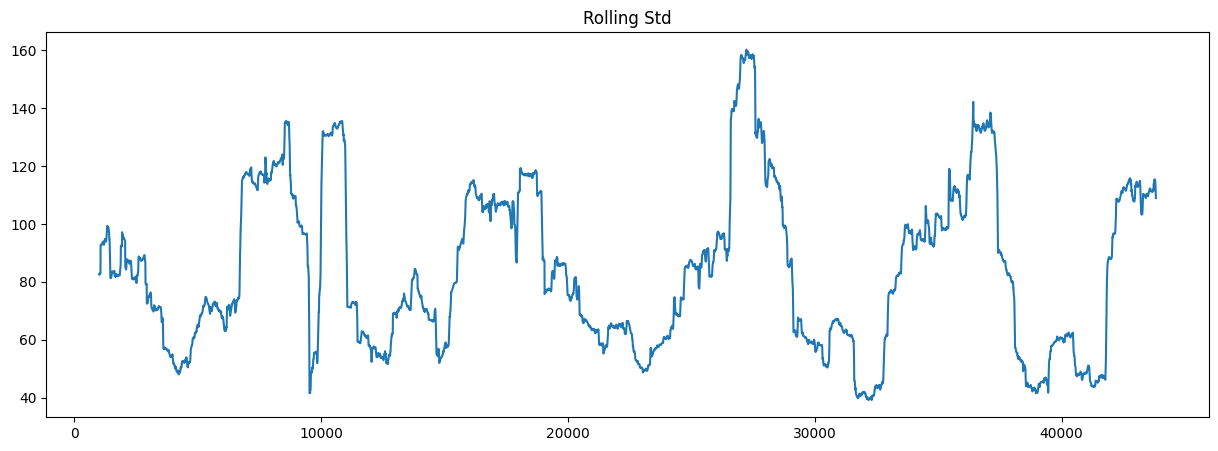

In [34]:
plt.figure(figsize=(15,5))
plt.plot(rolling_std)
plt.title("Rolling Std")
plt.show()


In [38]:
result = adfuller(series)
print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -21.347130264676267
p-value: 0.0


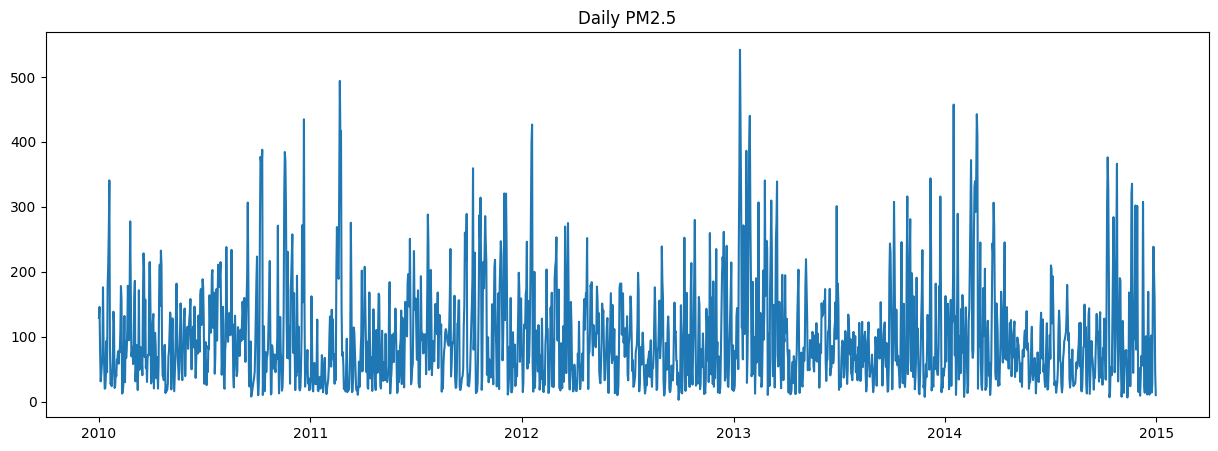

In [46]:
# Downsample to daily mean
daily_series = series.resample('D').mean()

plt.figure(figsize=(15,5))
plt.plot(daily_series)
plt.title("Daily PM2.5")
plt.show()

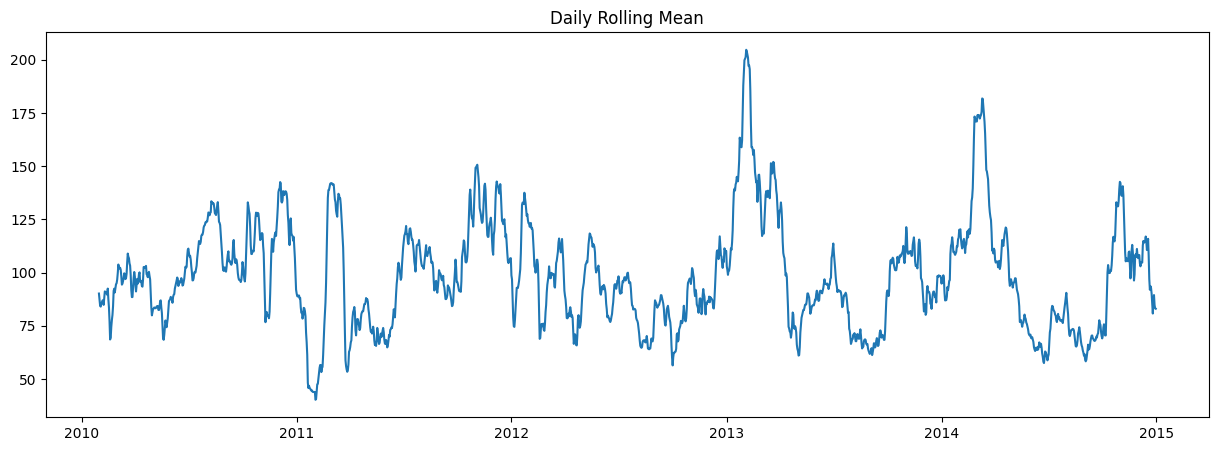

In [47]:

# Rolling stats for daily
rolling_mean_daily = daily_series.rolling(30).mean()
rolling_std_daily = daily_series.rolling(30).std()

plt.figure(figsize=(15,5))
plt.plot(rolling_mean_daily)
plt.title("Daily Rolling Mean")
plt.show()

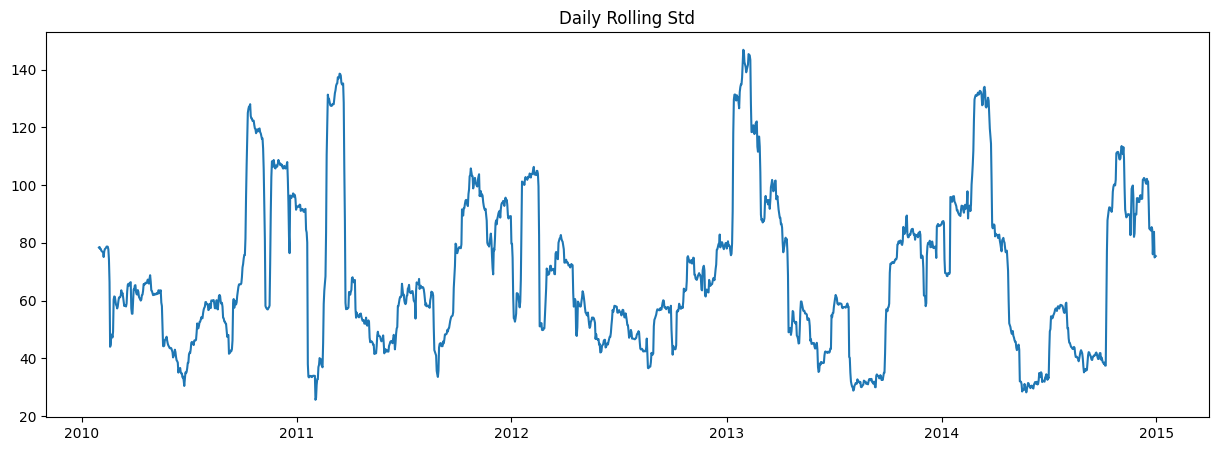

In [48]:

plt.figure(figsize=(15,5))
plt.plot(rolling_std_daily)
plt.title("Daily Rolling Std")
plt.show()

In [51]:
result_daily = adfuller(daily_series.dropna())
print("Daily ADF:", result_daily[0])
print("Daily p-value:", result_daily[1])

Daily ADF: -10.127729901336146
Daily p-value: 9.087760858922728e-18


/tmp/ipykernel_339/3886005011.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  upsampled = series.resample('30T').interpolate()


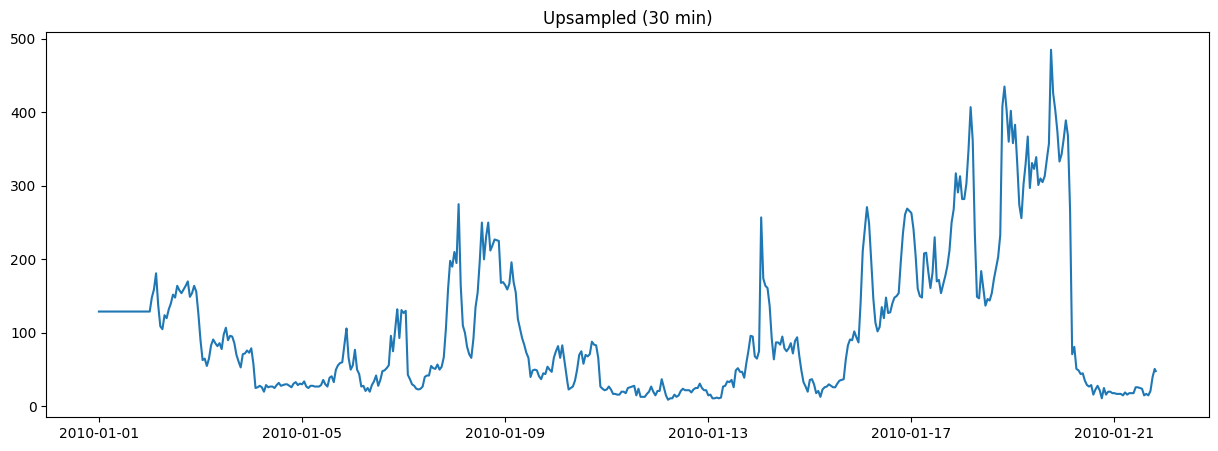

In [50]:
# Upsample to 30 minutes (interpolation)
upsampled = series.resample('30T').interpolate()

plt.figure(figsize=(15,5))
plt.plot(upsampled[:1000])  # 只画一小段
plt.title("Upsampled (30 min)")
plt.show()


In [52]:
result_up = adfuller(upsampled.dropna())
print("Upsampled ADF:", result_up[0])
print("Upsampled p-value:", result_up[1])


Upsampled ADF: -23.653493605959106
Upsampled p-value: 0.0


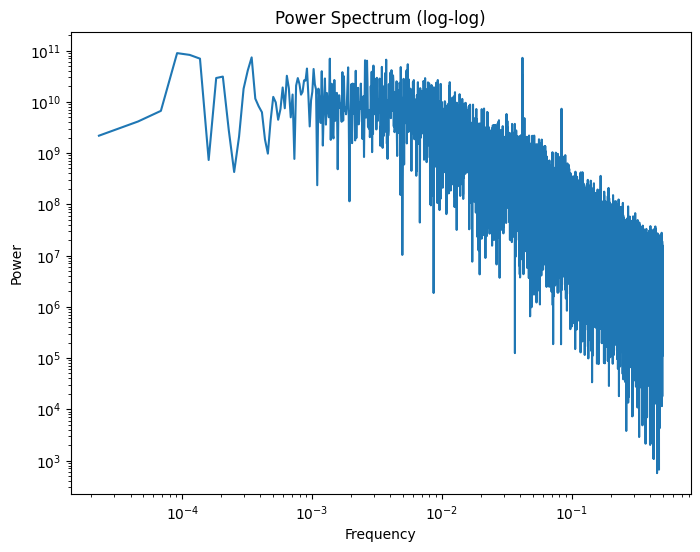

In [53]:
# remove mean
detrended = series - np.mean(series)

# FFT
fft_vals = np.fft.fft(detrended)
fft_freq = np.fft.fftfreq(len(detrended), d=1)

# only positive frequencies
positive = fft_freq > 0
power = np.abs(fft_vals[positive])**2
freqs = fft_freq[positive]

plt.figure(figsize=(8,6))
plt.loglog(freqs, power)
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.title("Power Spectrum (log-log)")
plt.show()

# @title Noam continues with the questions 1 and 3
    1. What is the temporal signature of the signal?
    3. How can we differentiate measurement error, from intrinsic fluctuations, and extrinsic perturbations?


In [54]:
# @title Uploading dataset
df = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv')

In [55]:
# @title Fixing pm2.5 with linear values with the days before after kind of thing

# The values will be replaced with the linear method as it compares witht the days before and after
df['pm2.5'] = df['pm2.5'].interpolate(method='linear')

# the remaining will be replaced with the next value of the day
df['pm2.5'] = df['pm2.5'].fillna(method='bfill').fillna(method='ffill')

df.isna().sum()

# fixed it lol

/tmp/ipykernel_339/300272976.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['pm2.5'] = df['pm2.5'].fillna(method='bfill').fillna(method='ffill')


,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,0
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [56]:
# @title  label encoding cbwd

# This is the wind-direction etc...
print(df['cbwd'].unique())

# 'NW' --> North West               0
# 'cv' --> calm and variable        1
# 'NE' --> North East               2
# 'SE' --> South East               3


label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(df["cbwd"])


print(list(label_encoder.classes_))
print()
print(label_encoder.transform(df["cbwd"]))

df["cbwd_encoded"] = label_encoder.transform(df["cbwd"])


df = df.drop(columns=['cbwd'])


['NW' 'cv' 'NE' 'SE']
['NE', 'NW', 'SE', 'cv']

[1 1 1 ... 1 1 1]


In [57]:
# @title Checking out the cbwd_encoded
print(df['cbwd_encoded'].value_counts())

# 'NW' --> North West               0 --> 4997
# 'cv' --> calm and variable        1 --> 14150
# 'NE' --> North East               2 --> 15290
# 'SE' --> South East               3 --> 9387

cbwd_encoded
2    15290
1    14150
3     9387
0     4997
Name: count, dtype: int64


In [59]:
df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'],day=df['day'] ))

## Exploring further




After normalizing the values, we can see that there are some patterns in this.

so for instance we can see according to the book that


For the notion of emergence, to see how the componentns work with each other, it is best how strongly each variable correlate with each other.
So for that the corr matrix is employed.





Temporal signature is applied in the dataset when you look at the various time-periods. There is mainly a peak for instance at the target variable, pollution, during new years, and it fades to the standard level again after some time...


While for the pollution, there is not really a first order for change, there is for temperature and pressure to some extent. It is quite predictable what those are going to be every day in the year.

However, it does contain second order of change as well. The temperature and pressure oscillates in every time frame there is.



# What is the temporal signature of the signal?


## Show the Temporal signature graphs

### First order of change

### Second order of change

### Third order of change

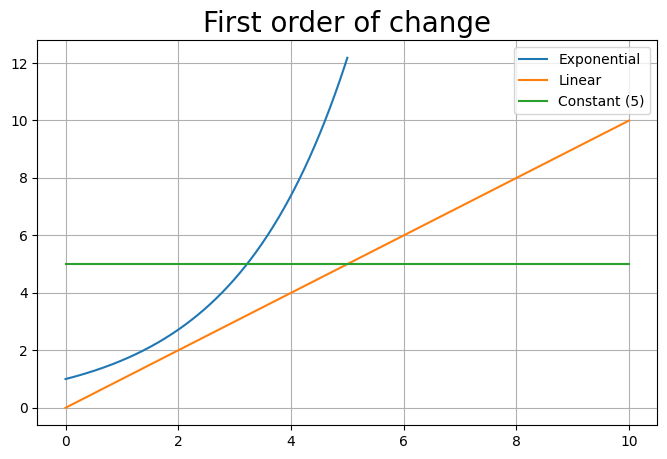

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
# @title First order of change
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# exponential
x_exp = np.linspace(0, 5, 500)
y_exp = np.exp(0.5 * x_exp)

# Linear
x_lin = np.linspace(0, 10, 1000)
y_lin = x_lin

# no change
x_const = np.linspace(0, 10, 100)
y_const = [5]*100

# ---- One combined plot ----
plt.figure(figsize=(8,5))

plt.plot(x_exp, y_exp, label="Exponential")
plt.plot(x_lin, y_lin, label="Linear")
plt.plot(x_const, y_const, label="Constant (5)")

plt.legend()
plt.title("First order of change", fontsize=20)
plt.grid(True)

# Save the plot before showing
plt.savefig('first_order_change.png', dpi=300)

# Display the plot
plt.show()

# Download the image
files.download('first_order_change.png')

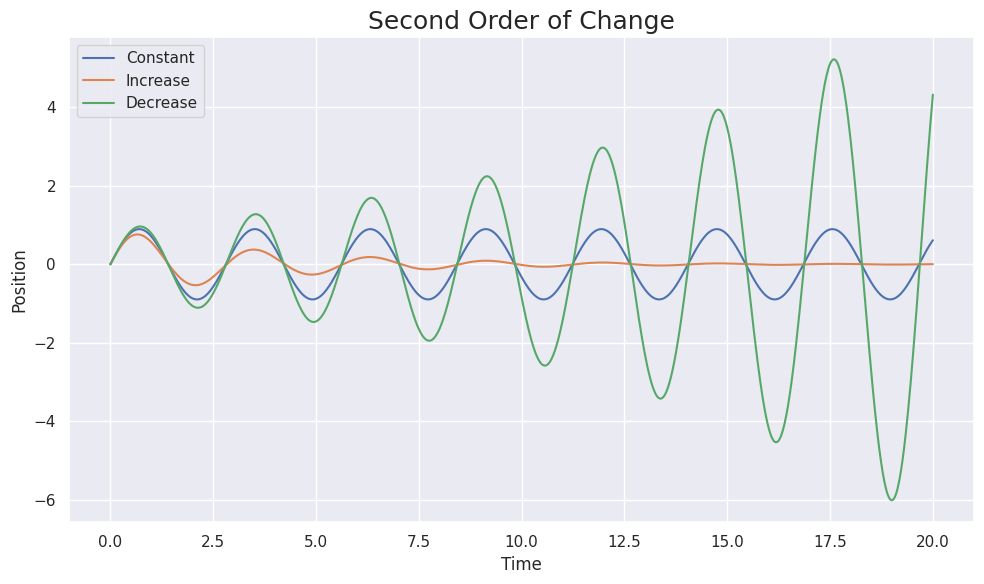

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title Second order of Change Oscillations

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set()

t = np.linspace(0, 20, 1000)
omega_sqr = 5
y0 = [0, 2]   # initial conditions

def oscillator(t, y, gamma):
    return [y[1], -gamma*y[1] - omega_sqr*y[0]]

plt.figure(figsize=(10,6))

# Constant
sol1 = solve_ivp(lambda t,y: oscillator(t,y,0), [0,20], y0, t_eval=t)
plt.plot(t, sol1.y[0], label="Constant")

# Increase
sol2 = solve_ivp(lambda t,y: oscillator(t,y,0.5), [0,20], y0, t_eval=t)
plt.plot(t, sol2.y[0], label="Increase")

# Decrease
sol3 = solve_ivp(lambda t,y: oscillator(t,y,-0.2), [0,20], y0, t_eval=t)
plt.plot(t, sol3.y[0], label="Decrease")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Second Order of Change", fontsize=18)
plt.legend()
plt.tight_layout()

# Save the plot BEFORE showing
plt.savefig('second_order_change.png', dpi=300)

# Display the plot
plt.show()

# Download the image
files.download('second_order_change.png')

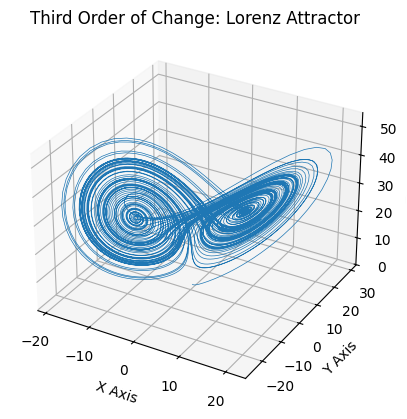

In [72]:
import matplotlib.pyplot as plt
import numpy as np


def lorenz(xyz, *, s=10, r=28, b=2.667):
    """
    Parameters
    ----------
    xyz : array-like, shape (3,)
       Point of interest in three-dimensional space.
    s, r, b : float
       Parameters defining the Lorenz attractor.

    Returns
    -------
    xyz_dot : array, shape (3,)
       Values of the Lorenz attractor's partial derivatives at *xyz*.
    """
    x, y, z = xyz
    x_dot = s*(y - x)
    y_dot = r*x - y - x*z
    z_dot = x*y - b*z
    return np.array([x_dot, y_dot, z_dot])


dt = 0.01
num_steps = 10000

xyzs = np.empty((num_steps + 1, 3))  # Need one more for the initial values
xyzs[0] = (0., 1., 1.05)  # Set initial values
# Step through "time", calculating the partial derivatives at the current point
# and using them to estimate the next point
for i in range(num_steps):
    xyzs[i + 1] = xyzs[i] + lorenz(xyzs[i]) * dt

# Plot
ax = plt.figure().add_subplot(projection='3d')

ax.plot(*xyzs.T, lw=0.5)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Third Order of Change: Lorenz Attractor")
plt.savefig('Third Order of Change: Lorenz Attractor')
plt.show()



In [ ]:
print(df.columns)

Index(['year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws',
       'Is', 'Ir', 'cbwd_encoded', 'date'],
      dtype='object')


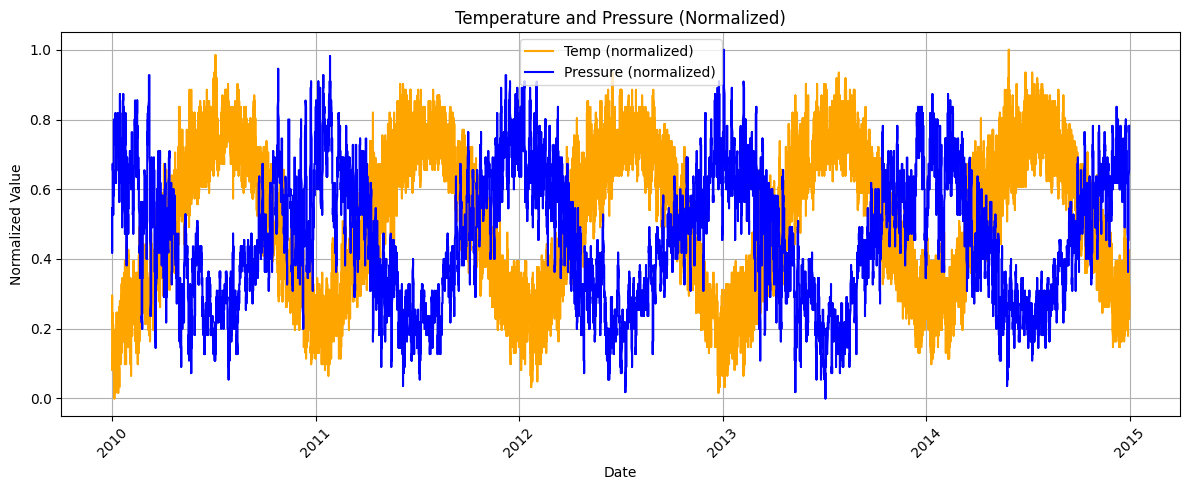

In [77]:
# @title Checking out the relationship between Pressure and Temperature.

temp_norm = (df['TEMP'] - df['TEMP'].min()) / (df['TEMP'].max() - df['TEMP'].min())
pres_norm = (df['PRES'] - df['PRES'].min()) / (df['PRES'].max() - df['PRES'].min())

plt.figure(figsize=(12,5))
plt.plot(df['date'], temp_norm, label='Temp (normalized)', color='orange')
plt.plot(df['date'], pres_norm, label='Pressure (normalized)', color='blue')
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.title('Temperature and Pressure (Normalized)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('Temperature and Pressure (Normalized)')
plt.show()

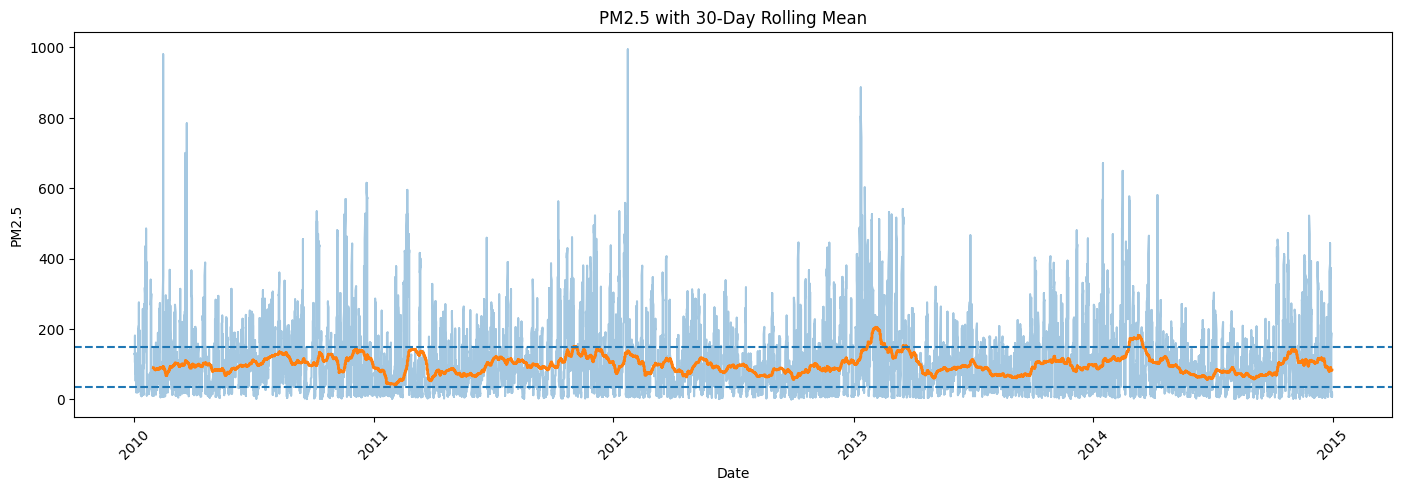

In [76]:
df['date_monthly'] = pd.to_datetime(dict(year=df['year'], month=df['month'],day=df['day'] ))


# 30-day rolling mean (hourly data → 720 hours)
rolling_mean = df['pm2.5'].rolling(window=720).mean()

plt.figure(figsize=(17,5))
plt.plot(df['date_monthly'], df['pm2.5'], alpha=0.4)
plt.plot(df['date_monthly'], rolling_mean, linewidth=2)

plt.axhline(35, linestyle='--')
plt.axhline(150, linestyle='--')

plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("PM2.5 with 30-Day Rolling Mean")
plt.xticks(rotation=45)
plt.savefig("PM2.5 with 30-Day Rolling Mean.png")
plt.show()


